IMPORT LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# warnings
import warnings
warnings.filterwarnings('ignore')

LOAD DATASET

In [ ]:
df = pd.read_csv('/content/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


BASIC INFO

In [ ]:
print("Shape:", df.shape)

Shape: (7500, 16)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [ ]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


DATA CLEANING

In [ ]:
#Drop unnecessary columns
df.drop(['user_id', 'transaction_id'], axis=1, inplace=True, errors='ignore')

In [ ]:
#missing values
df.isnull().sum()

# Fill categorical missing values
df['addiction_level'].fillna('Unknown', inplace=True)

In [ ]:
#remove duplicates
df.drop_duplicates(inplace=True)

OUTLIER DETECTION

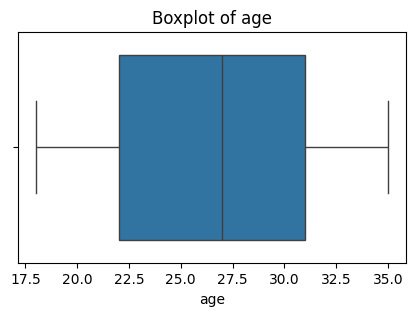

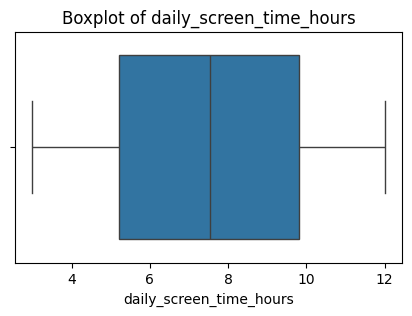

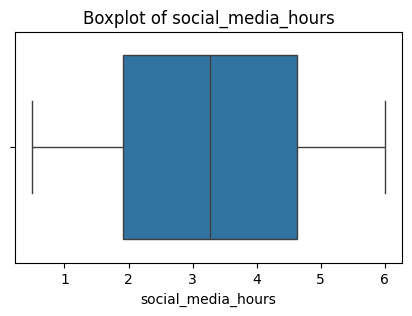

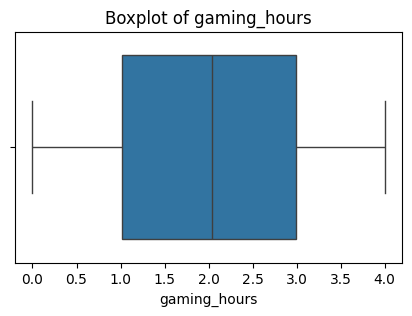

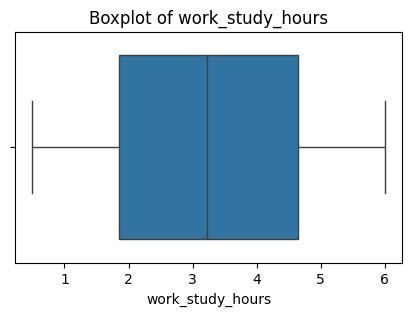

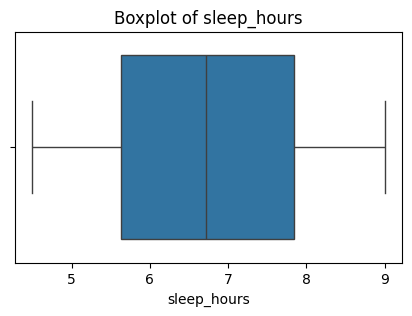

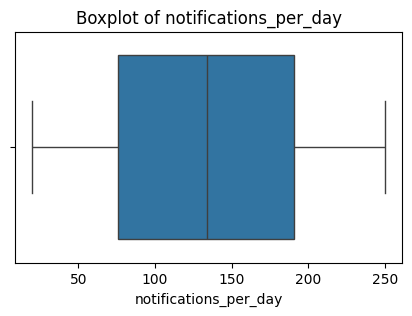

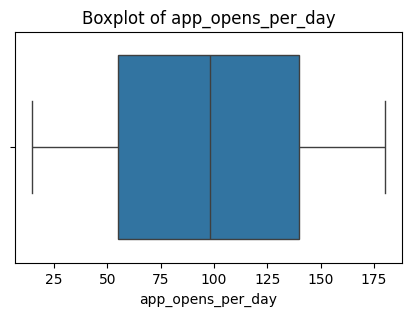

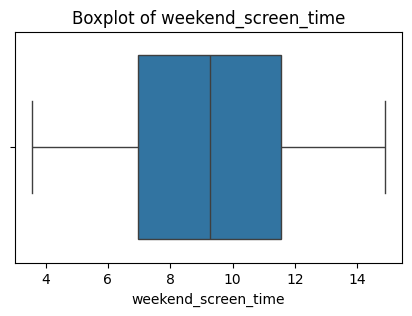

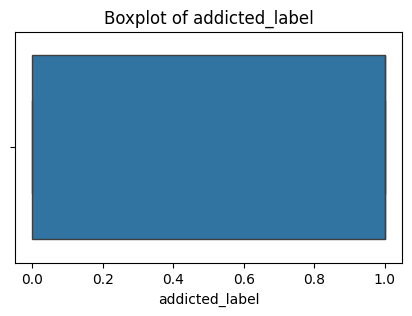

In [ ]:
#boxplot
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
#IQR method
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper, upper,
                       np.where(df[col] < lower, lower, df[col]))

UNIVARIATE ANALYSIS-  numerical

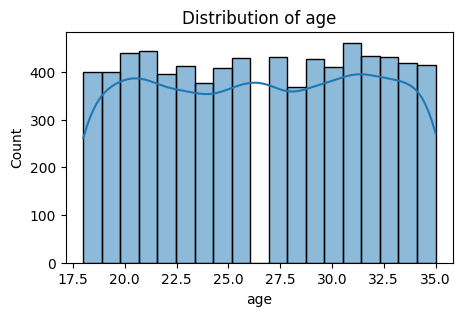

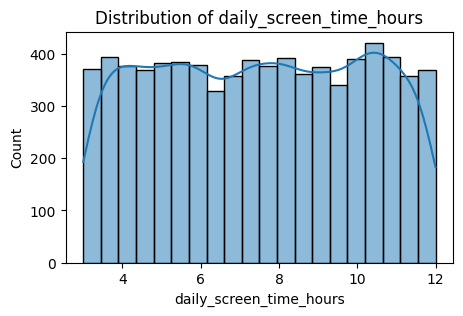

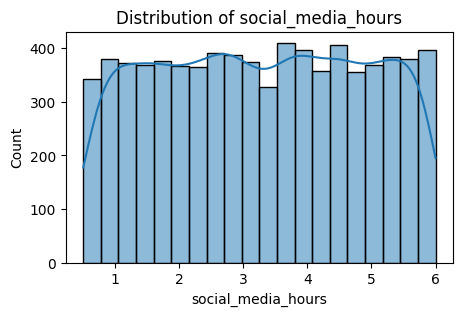

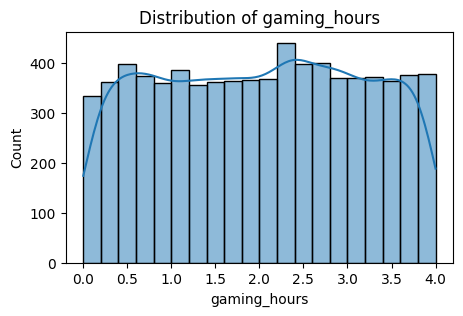

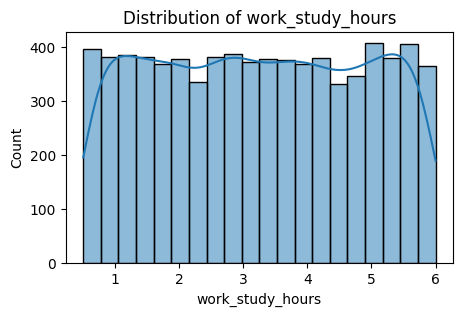

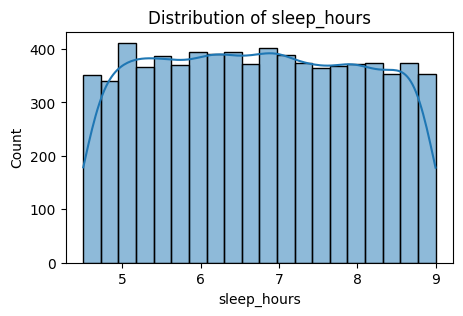

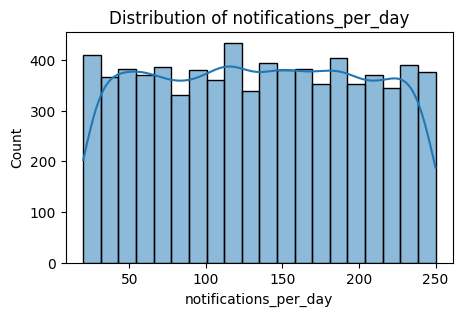

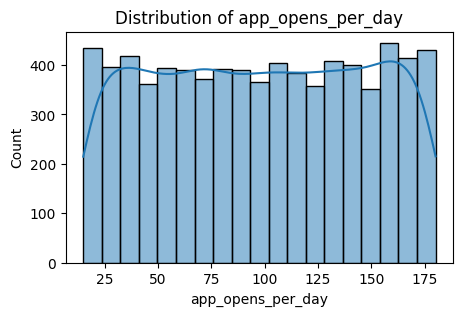

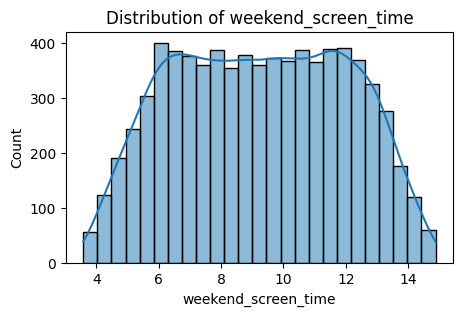

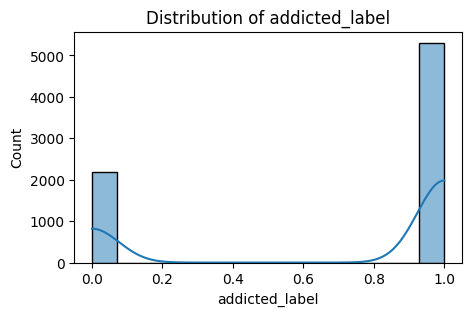

In [ ]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

UNIVARIATE ANALYSIS- categorical

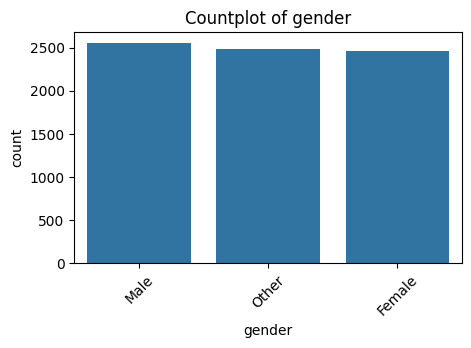

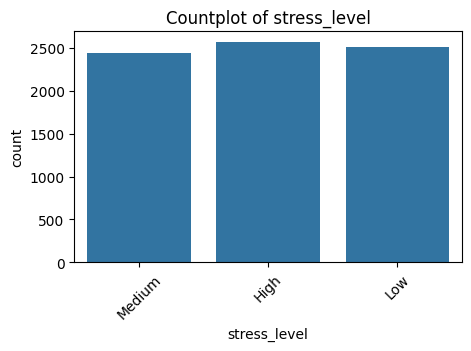

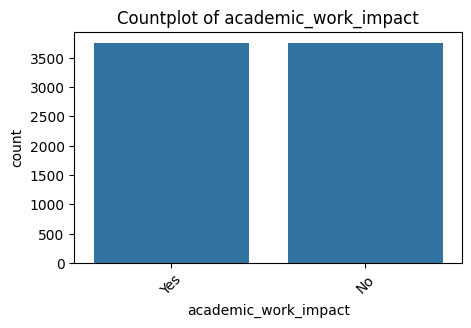

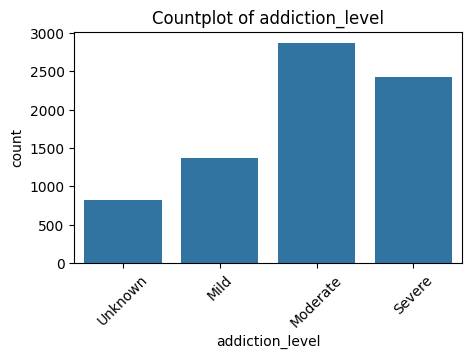

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(f'Countplot of {col}')
    plt.show()

BIVARIATE ANALYSIS- Numerical vs target

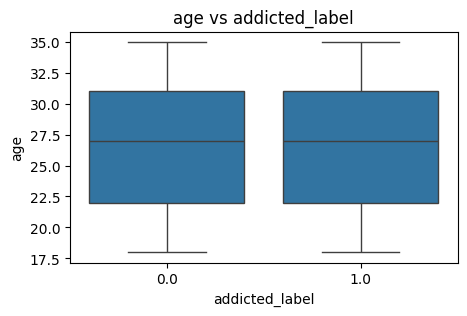

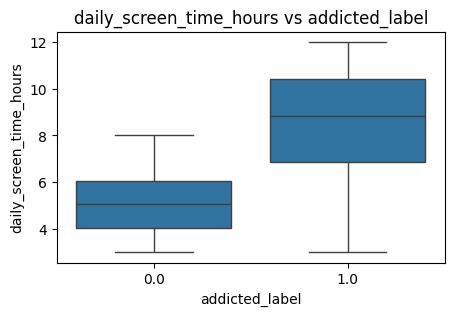

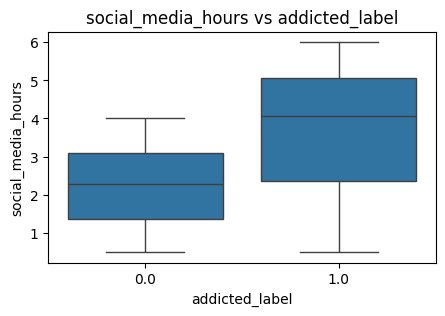

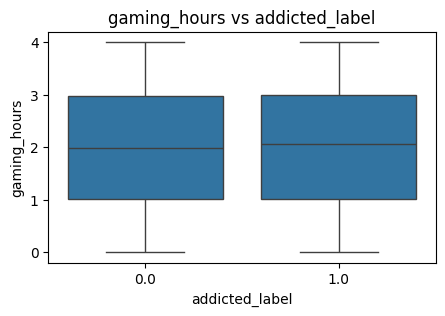

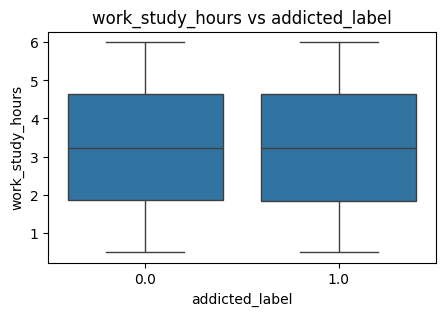

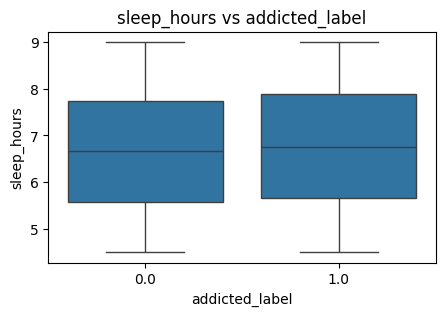

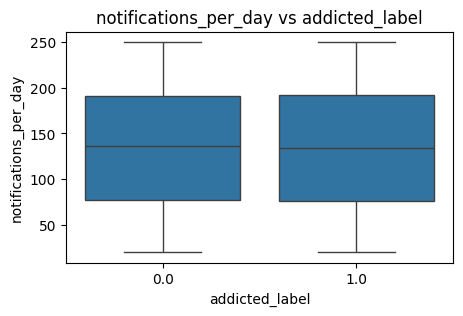

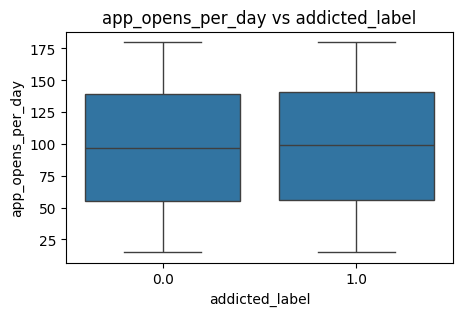

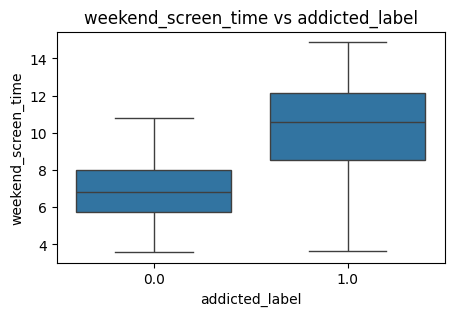

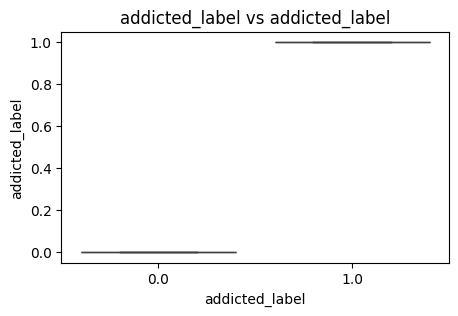

In [ ]:
target = 'addicted_label'

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[target], y=df[col])
    plt.title(f'{col} vs {target}')
    plt.show()

BIVARIATE ANALYSIS- Categorical vs Target

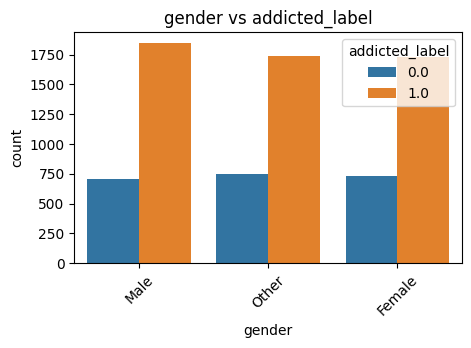

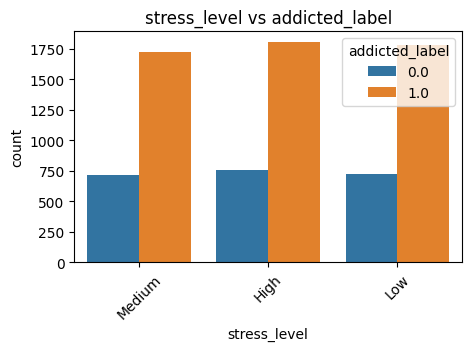

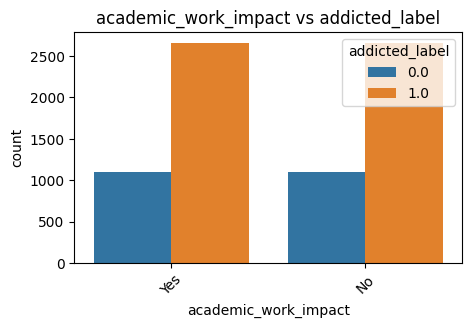

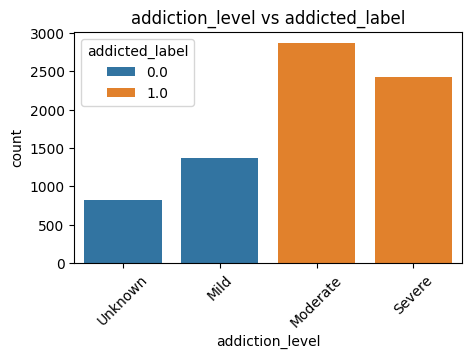

In [ ]:
for col in cat_cols:
    if col != target:
        plt.figure(figsize=(5,3))
        sns.countplot(x=df[col], hue=df[target])
        plt.xticks(rotation=45)
        plt.title(f'{col} vs {target}')
        plt.show()

BIVARIATE ANALYYSIS- correlation heatmap

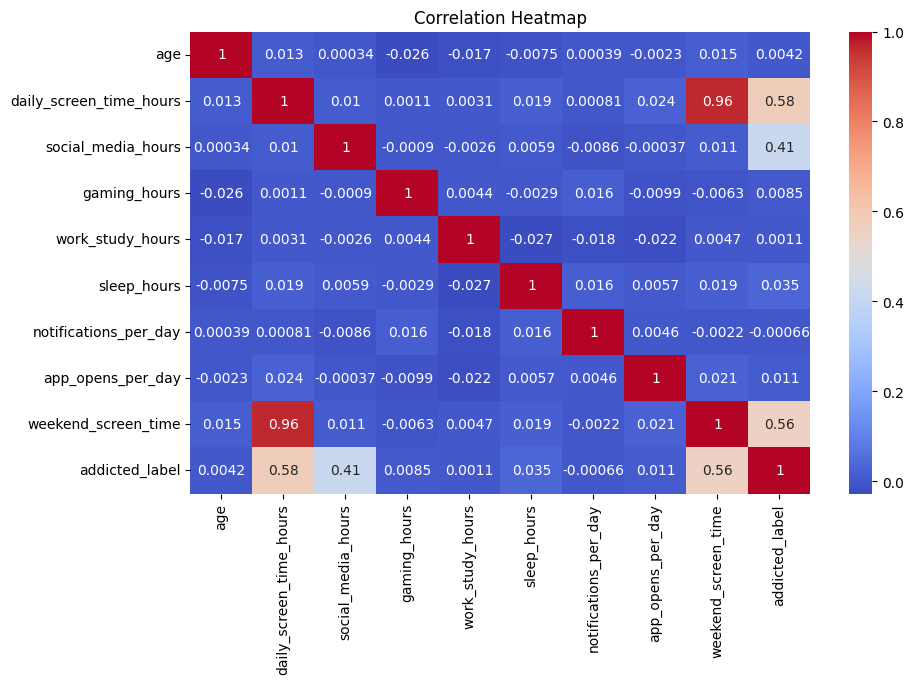

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

FEATURE ENGINEERING

In [ ]:
def usage_category(x):
    if x < 3:
        return 'Low'
    elif x < 6:
        return 'Medium'
    else:
        return 'High'

df['usage_category'] = df['daily_screen_time_hours'].apply(usage_category)

In [ ]:
#app usage intensity
df['app_usage_intensity'] = df['app_opens_per_day'] / (df['daily_screen_time_hours'] + 1)

In [ ]:
#heavy user flags
df['is_heavy_user'] = df['daily_screen_time_hours'].apply(lambda x: 1 if x > 6 else 0)

ENCODING

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

TRAIN-TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('addicted_label', axis=1)
y = df['addicted_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

FEATURE SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9066666666666666
              precision    recall  f1-score   support

         0.0       0.86      0.83      0.84       456
         1.0       0.93      0.94      0.93      1044

    accuracy                           0.91      1500
   macro avg       0.89      0.89      0.89      1500
weighted avg       0.91      0.91      0.91      1500

